<a href="https://colab.research.google.com/github/Prakruthi2606/Mall-customers-segmentation/blob/main/Mall_Customers_Clustering(KMeans).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Mall Customers Clustering**

The objective of this project is to apply **K-Means clustering** on the **Mall Customers dataset** to **identify distinct customer segments** based on features such as age, income, and spending score. These segments can help businesses personalize marketing strategies, improve customer experience, and increase revenue.

**Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

**Load data**

In [ ]:
df = pd.read_csv('Mall_Customers.csv')

In [ ]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [ ]:
# check the data type
df.dtypes

,0
CustomerID,int64
Gender,object
Age,int64
Annual Income (k$),int64
Spending Score (1-100),int64


In [ ]:
num_col= df.select_dtypes(include=['int64','float64'])
num_col

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,2,21,15,81
2,3,20,16,6
3,4,23,16,77
4,5,31,17,40
...,...,...,...,...
195,196,35,120,79
196,197,45,126,28
197,198,32,126,74
198,199,32,137,18


In [ ]:
cat_col= df.select_dtypes(include=['object'])
cat_col

,Gender
0,Male
1,Male
2,Female
3,Female
4,Female
...,...
195,Female
196,Female
197,Male
198,Male


**Handling missing values**

In [ ]:
#check for missing values
df.isnull().sum()


,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
#check for duplicates
df.duplicated().sum()

np.int64(0)

**EDA**

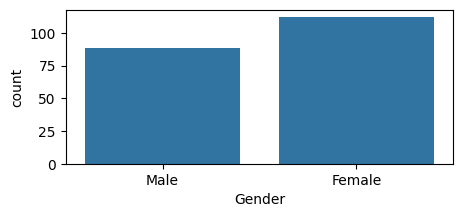

In [ ]:
# Distribution of categorical features (Countplot)
plt.figure(figsize=(5,2))
sns.countplot(df,x='Gender')
plt.show()

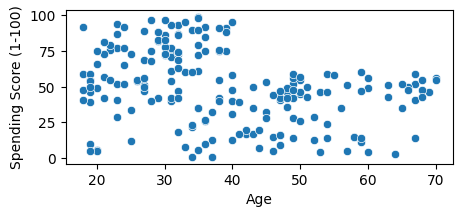

In [ ]:
#Find relationship btween age and spending score
plt.figure(figsize=(5,2))
sns.scatterplot(df,x='Age',y='Spending Score (1-100)')
plt.show()

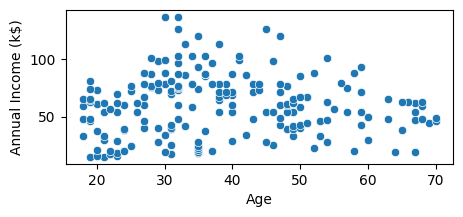

In [ ]:
# Find relationship between Age and Annual Income (k$)
plt.figure(figsize=(5,2))
sns.scatterplot(df,x='Age',y='Annual Income (k$)')
plt.show()

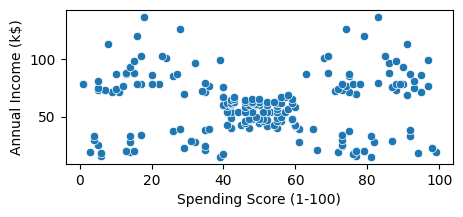

In [ ]:
#Find relationship between Annual Income (k$) and Spending Score(1-100)
plt.figure(figsize=(5,2))
sns.scatterplot(df,x='Spending Score (1-100)',y='Annual Income (k$)')
plt.show()

**Encoding**

In [ ]:
# gender --> male , female
df = pd.get_dummies(df,columns=['Gender'],dtype='int')

In [ ]:
# Scaling ;Age	Annual Income (k$)	Spending Score (1-100)
from sklearn.preprocessing import StandardScaler
model = StandardScaler()
df[['Age']]=model.fit_transform(df[['Age']])
df[['Annual Income (k$)']]=model.fit_transform(df[['Annual Income (k$)']])
df[['Spending Score (1-100)']]=model.fit_transform(df[['Spending Score (1-100)']])



**Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler
model = StandardScaler()
df[['Age']]=model.fit_transform(df[['Age']])
df[['Annual Income (k$)']]=model.fit_transform(df[['Annual Income (k$)']])
df[['Spending Score (1-100)']]=model.fit_transform(df[['Spending Score (1-100)']])


**KMeans Model Training**

In [ ]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters=5)
model.fit(df)

KMeans(n_clusters=5)

In [ ]:
data = df.copy()

In [ ]:
data['clusters'] = model.predict(df)


In [ ]:
data['clusters'].unique()

array([1, 2, 4, 3, 0], dtype=int32)

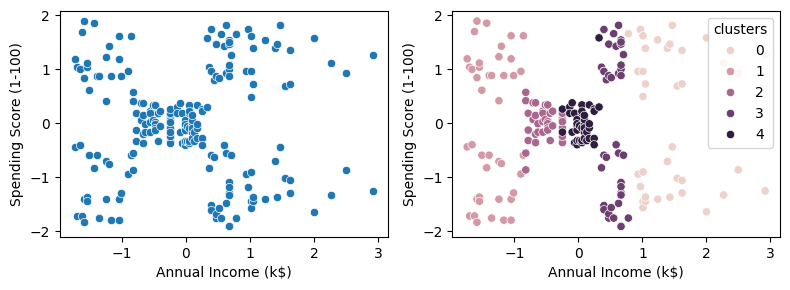

In [ ]:
# visualise the clusters annaul income v/s spendinng score
fig,ax = plt.subplots(1,2,figsize=(8,3))
sns.scatterplot(data,x='Annual Income (k$)',y='Spending Score (1-100)',ax=ax[0])
sns.scatterplot(data,x='Annual Income (k$)',y='Spending Score (1-100)',hue='clusters',ax=ax[1])
plt.tight_layout()

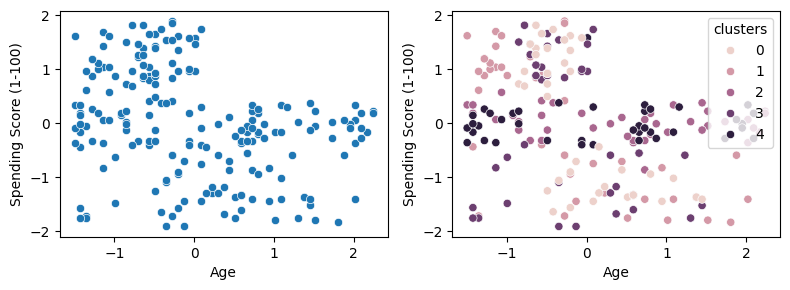

In [ ]:
# visualise the clusters age v/s spendinng score
fig,ax = plt.subplots(1,2,figsize=(8,3))
sns.scatterplot(data,x='Age',y='Spending Score (1-100)',ax=ax[0])
sns.scatterplot(data,x='Age',y='Spending Score (1-100)',hue='clusters',ax=ax[1])
plt.tight_layout()

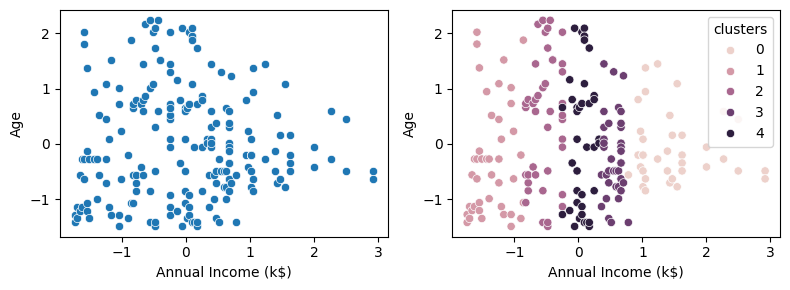

In [ ]:
# visualise the clusters annual income v/s age
fig,ax = plt.subplots(1,2,figsize=(8,3))
sns.scatterplot(data,x='Annual Income (k$)',y='Age',ax=ax[0])
sns.scatterplot(data,x='Annual Income (k$)',y='Age',hue='clusters',ax=ax[1])
plt.tight_layout()

In [ ]:
# labels
labels = model.predict(df)
labels

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0], dtype=int32)

In [ ]:
from sklearn.metrics import silhouette_score
silhouette_score(df,labels)

np.float64(0.5413913090029012)

**Elbow method**

In [ ]:
wcss =[]
for k in range(2,11):
  model = KMeans(n_clusters=k)
  model.fit(df)
  wcss.append(model.inertia_)


In [ ]:
wcss

[167268.2465726907,
 74633.24413384283,
 42287.88009329812,
 27416.678317197937,
 19165.568149504466,
 14537.112973753168,
 10959.243942856909,
 8753.761714488744,
 7333.82980945763]

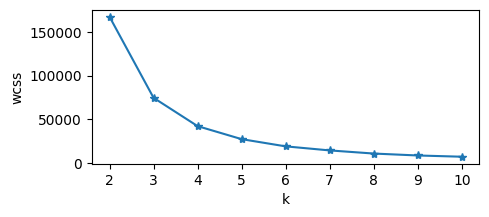

In [ ]:
plt.figure(figsize=(5,2))
plt.plot(range(2,11),wcss , marker='*')
plt.xlabel('k')
plt.ylabel('wcss')
plt.show()

In [ ]:
df1 = df.copy()

In [ ]:
# k = 5
model = KMeans(n_clusters=5)
model.fit(df)

KMeans(n_clusters=5)

In [ ]:
df1['clusters']=model.predict(df)

In [ ]:
df1['clusters'].unique()

array([3, 1, 0, 4, 2], dtype=int32)

In [ ]:
labels=model.predict(df)

In [ ]:
silhouette_score(data,labels)

np.float64(0.5420718173117974)

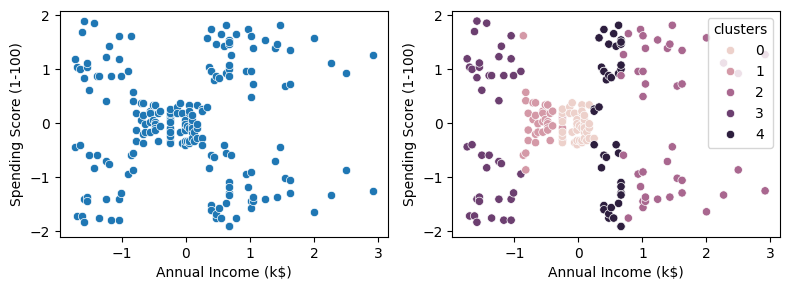

In [ ]:
# visualize the clusters annual income v/s spendinng score
fig,ax = plt.subplots(1,2,figsize=(8,3))
sns.scatterplot(df1,x='Annual Income (k$)',y='Spending Score (1-100)',ax=ax[0])
sns.scatterplot(df1,x='Annual Income (k$)',y='Spending Score (1-100)',hue='clusters',ax=ax[1])
plt.tight_layout()

### **Conclusion**

The model has successfully captured the five distinct "consumer personas" within the mall's ecosystem:

* Cluster 0 (The Average Consumer): Mid-income, mid-spending. This is likely the largest, most stable segment.

* Cluster 1 (High Earners, Low Spenders): High income but conservative spending. These are "frugal" high-income individuals who might need specific incentives or luxury experiences to increase their spending.

* Cluster 2 (Low Earners, Low Spenders): This group is budget-conscious. They likely visit for necessities rather than impulse buys.

* Cluster 3 (Low Earners, High Spenders): Often referred to as "Impetuous" or "Young" spenders. They have lower income but a very high spending score—likely the most responsive group to trends and flash sales.

* Cluster 4 (High income and high spending): These are your "VIP" or "Premium" customers. Marketing efforts should focus heavily on retaining this group through loyalty programs.

**Business Recommendations:**
<br>
Based on these five clusters, you can now propose a Targeted Marketing Strategy:

* Retention: Focus on Cluster 4 with exclusive previews and concierge services.

* Conversion: Target Cluster 1 with personalized offers to see if their spending can be moved closer to Cluster 4.

* Engagement: Use social media and trend-based marketing for Cluster 3.